# NB-2 - Statistical Thinking
**MAM5017S 2026 · Lecture 2**

A neuron fires more often when a visual stimulus appears. Is that a real response, or did we happen to record a noisy set of trials? This notebook follows that question through the full *scientific process*. We will inspect the raw data, measure the signal and the noise, build a world in which the stimulus has no effect, and decide what the experiment can support.

We have more time with each idea here than we had in the lecture. We will use the same sequence throughout.

1. Predict what you expect before seeing the result.
2. Run one small piece of code.
3. Read the output in plain language.
4. Explain what it changes about the scientific claim.

There are nine main **Try it** tasks and one optional extension. They require short answers and small code changes. The notebook is marked for attempting the main tasks. You may use an AI assistant, but you should be able to explain every number if asked in an oral exam.

## What will you be able to do by the end?

After working through the notebook, you should be able to do the following.

- Map a neuroscience question onto the **scientific process loop**.
- Treat a `pandas` DataFrame as a record of observations and variables.
- Use **exploratory data analysis** to inspect distributions, typical values, variability, drift, and outliers.
- Distinguish a sample distribution from a **sampling distribution** and explain why standard error shrinks with sample size.
- Build a **permutation null distribution** by shuffling condition labels.
- Compute a **Welch two-sample t-test** from its parts and confirm it with SciPy.
- Interpret a **p-value** and a **95% confidence interval** without giving either more meaning than it has.
- Distinguish **Type I** and **Type II** errors and explain the trade-off between significance level and power.
- Report the raw effect, uncertainty, and **Cohen's d** together.
- As an optional extension, show why a two-group t-test is a regression with a binary feature.

## What should already be familiar?

This notebook is written for students who have completed the Python foundations work, Lecture 1, and Lecture 2. You should be comfortable running cells, reading a small DataFrame, interpreting a histogram, and working with a mean and standard deviation. Part 11 returns to the linear regression from Lecture 1.

You do not need to know a hypothesis-testing method before you start. Sampling distributions, permutation tests, confidence intervals, error rates, power, and effect size are taught here as we need them.

## What route will we take?

| Part | Question | Main output |
|---:|---|---|
| 1 | How does a question become a statistical claim? | A pre-analysis plan |
| 2 | What experiment are we running? | A reproducible trial table |
| 3 | Is the dataset what we think it is? | A data audit |
| 4 | What do the raw data look like? | Histograms, trial plots, boxplots, and an outlier check |
| 5 | Why do larger samples give steadier answers? | Sampling distributions and standard errors |
| 6 | What would we see if the stimulus did nothing? | A permutation null distribution |
| 7 | How does a t-test quantify the same idea? | `t`, `p`, and a 95% confidence interval |
| 8 | How can a decision be wrong? | False-positive and power simulations |
| 9 | How large is the effect? | Raw effect, Cohen's `d`, and a paper-review exercise |
| 10 | What does `p < 0.05` mean? | A precise interpretation of the p-value |
| 11 | How is this the regression from Lecture 1? | The same estimate written as a model weight |
| 12 | What can we conclude? | A complete statistical report and a next experiment |

The main route is Parts 1–10 and Part 12. Part 11 is an optional return to the regression from Lecture 1. The main route uses NumPy, pandas, Matplotlib, and SciPy. Part 11 also uses scikit-learn. The notebook downloads no data. Allow roughly **two hours** for the main route and another **15 minutes** for Part 11. If you need a break, take it after Part 5.

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.precision", 2)

# Independent random-number generators keep each simulation reproducible.
rng_data = np.random.default_rng(0)
rng_plot = np.random.default_rng(2026)

# Fixed course colours, reused across notebooks.
C_TRAIN = "#185FA5"
C_TEST = "#D85A30"
C_NEURO = "#0E8C76"
C_LOSS = "#C0392B"
C_NEUTRAL = "#667085"

# In this notebook the two experimental conditions use these aliases.
C_BASELINE = C_TRAIN
C_STIM = C_TEST

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
})

print("Setup complete. NumPy, pandas, Matplotlib, and SciPy are ready.")

Setup complete. NumPy, pandas, Matplotlib, and SciPy are ready.


## 1. How does a question become a statistical claim?

Statistics is one part of a larger scientific loop. A test is useful only when the question, sample, and measurement make sense. In other words, we must know what was observed and how those observations connect to the hypothesis before interpreting the result.

| Stage | In our experiment |
|---|---|
| **Observation** | A visual stimulus seems to change a neuron's activity. |
| **Question** | Does presenting the stimulus change the neuron's mean spike count? |
| **Hypothesis** | The stimulus increases the mean count during a one-second trial. |
| **Prediction** | Repeated stimulus trials should tend to contain more spikes than baseline trials. |
| **Experiment** | Record the same neuron for many one-second trials, with and without the stimulus. |
| **Analysis** | Inspect the data, estimate the difference, quantify uncertainty, and compare the result with a null world. |
| **Inference** | State what the data support, what they do not settle, and what experiment should come next. |

We would next ask whether the effect replicates across neurons, animals, stimulus types, or recording sessions.

### Try it 1. What will you decide before seeing the data?

Imagine that the data have been recorded but you have not opened the file. Write down the following.

1. The **unit of observation** in this experiment.
2. The **outcome variable**.
3. The comparison that will count as the effect.
4. One plot you will make before running a test.
5. One reason a trial might deserve investigation without automatically being deleted.

Writing these choices down before opening the data makes the analysis easier to justify later.

**Your answer**

The unit of observation is a spike. The outcome is (count) number of spikes each stimulus gives. I will estimate the effect as the statistical difference between means of the baseline and experiment trials. Before testing I will plot a trial plot, a histogram plot and a box plot for both the baseline and experiment. I would investigate a trial if it appears to be an outlier.

## 2. What experiment are we running?

We will follow a single hypothetical V1 neuron, **Neuron 17**, across 80 one-second trials. Forty trials contain no stimulus and forty contain a visual stimulus. The baseline mean is 12 spikes per trial and the stimulated mean is 15. The true effect in the simulation is therefore **+3 spikes per trial**.

Spike counts are non-negative integers. A **Poisson distribution** is a useful starting model for counts of events in a fixed window. It assumes independent events at a constant rate, with equal mean and variance. Real neurons can burst, adapt, drift, or show more variability than the Poisson model allows. We will return to those limits when we interpret the result.

Why simulate the experiment? We know the population values that generated the data, so we can see how a noisy sample differs from them.

In [2]:
N_TRIALS = 40
TRUE_BASELINE = 12.0
TRUE_STIM = 15.0
TRUE_EFFECT = TRUE_STIM - TRUE_BASELINE

# Keep these two draws unchanged because they match the Lecture 2 example.
no_stim = rng_data.poisson(TRUE_BASELINE, size=N_TRIALS).astype(float)
stim = rng_data.poisson(TRUE_STIM, size=N_TRIALS).astype(float)

# Inject one known recording artefact so we have a concrete data-quality decision.
stim[7] = 34.0

df = pd.DataFrame({
    "neuron": "Neuron 17",
    "trial_in_condition": np.tile(np.arange(1, N_TRIALS + 1), 2),
    "condition": ["no stimulus"] * N_TRIALS + ["stimulus"] * N_TRIALS,
    "stimulus_on": np.repeat([0, 1], N_TRIALS),
    "spike_count": np.concatenate([no_stim, stim]),
})

print(f"Created {len(df)} one-second trials from {df['neuron'].nunique()} neuron.")
print(f"Known population effect in the simulation = {TRUE_EFFECT:.1f} spikes per trial.")

Created 80 one-second trials from 1 neuron.
Known population effect in the simulation = 3.0 spikes per trial.


### What does one row mean?

A DataFrame is a table in which each row is one observation and each column is one recorded variable. The first rows show whether we built that table correctly.

In [3]:
df.head(6)

,neuron,trial_in_condition,condition,stimulus_on,spike_count
0,Neuron 17,1,no stimulus,0,13.0
1,Neuron 17,2,no stimulus,0,3.0
2,Neuron 17,3,no stimulus,0,13.0
3,Neuron 17,4,no stimulus,0,16.0
4,Neuron 17,5,no stimulus,0,16.0
5,Neuron 17,6,no stimulus,0,14.0


Read the first row in words. It says that trial 1 for Neuron 17 was a no-stimulus trial, its numeric condition code was 0, and 13 spikes were recorded in one second. Our outcome is a *count in a fixed window*. Because the window is one second, the number happens to have the same numerical value as spikes per second.

### Try it 2. Does the trial table have the expected structure?

The cell below performs the three checks we would make before analysing any table. It inspects its shape, checks for missing values, and filters a subset. Change `condition_to_view` to the other condition and run the cell again.

In [6]:
condition_to_view = "no stimulus"  # change to "no stimulus" and rerun

print("rows, columns:", df.shape)
print("missing values:")
print(df.isna().sum())

subset = df.loc[df["condition"] == condition_to_view,
                ["trial_in_condition", "condition", "spike_count"]]
print(f"\nFirst five rows for {condition_to_view!r}:")
display(subset.head())
print(f"This filter returned {len(subset)} trials.")

rows, columns: (80, 5)
missing values:
neuron                0
trial_in_condition    0
condition             0
stimulus_on           0
spike_count           0
dtype: int64

First five rows for 'stimulus':


,trial_in_condition,condition,spike_count
40,1,stimulus,22.0
41,2,stimulus,19.0
42,3,stimulus,13.0
43,4,stimulus,12.0
44,5,stimulus,21.0


This filter returned 40 trials.


**Your answer**

Each row represents trials (stimulus and no stimulus). Each column represents experiment details/variables. The filter returned 40 rows for the stimulus condition and 40 rows for the no-stimulus condition. The missing-value check showed 0 missing values .

## 3. Is the dataset what we think it is?

Before calculating an effect, we should confirm the number of observations, the coding of the conditions, and the range of the outcome. These checks catch duplicated rows, an empty condition, or a variable read as text.

In [7]:
audit = pd.DataFrame({
    "check": [
        "number of rows",
        "conditions present",
        "trials per condition",
        "spike-count dtype",
        "minimum count",
        "maximum count",
    ],
    "observed": [
        len(df),
        ", ".join(sorted(df["condition"].unique())),
        df.groupby("condition").size().to_dict(),
        str(df["spike_count"].dtype),
        df["spike_count"].min(),
        df["spike_count"].max(),
    ],
    "expected": [
        80,
        "no stimulus, stimulus",
        "40 in each",
        "numeric",
        "0 or more",
        "plausible for this neuron",
    ],
})

audit

,check,observed,expected
0,number of rows,80,80
1,conditions present,"no stimulus, stimulus","no stimulus, stimulus"
2,trials per condition,"{'no stimulus': 40, 'stimulus': 40}",40 in each
3,spike-count dtype,float64,numeric
4,minimum count,3.0,0 or more
5,maximum count,34.0,plausible for this neuron


The maximum is 34 spikes. A count this high is possible, but it is far enough from the stimulated mean of 15 to deserve a closer look. We will keep it while we inspect the sample.

## 4. What do the raw data look like?

*Exploratory data analysis* means looking at the measurements from several angles before choosing how to summarise them. No single plot is sufficient.

- A **trial plot** can reveal drift, adaptation, or one bad recording.
- A **histogram** shows the shape and overlap of the two distributions.
- A **boxplot with raw points** shows the median, interquartile range, and individual observations together.

These plots describe the sample. A causal conclusion also depends on how the experiment was designed.

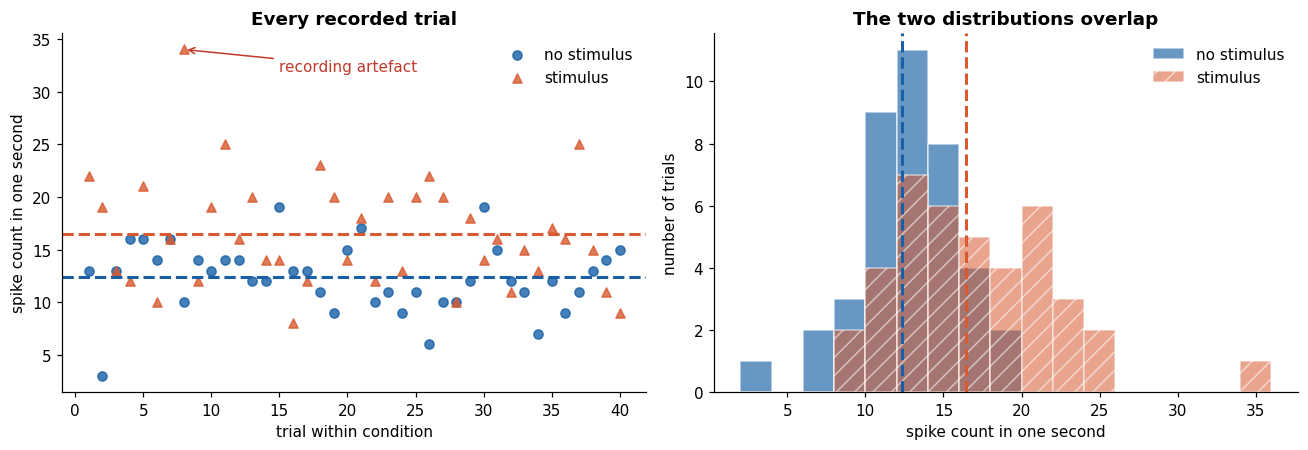

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].scatter(df.loc[df["stimulus_on"] == 0, "trial_in_condition"], no_stim,
                color=C_BASELINE, marker="o", alpha=0.8, label="no stimulus")
axes[0].scatter(df.loc[df["stimulus_on"] == 1, "trial_in_condition"], stim,
                color=C_STIM, marker="^", alpha=0.8, label="stimulus")
axes[0].axhline(no_stim.mean(), color=C_BASELINE, ls="--", lw=2)
axes[0].axhline(stim.mean(), color=C_STIM, ls="--", lw=2)
axes[0].annotate("recording artefact", xy=(8, 34), xytext=(15, 32),
                 arrowprops={"arrowstyle": "->", "color": C_LOSS}, color=C_LOSS)
axes[0].set(xlabel="trial within condition", ylabel="spike count in one second",
            title="Every recorded trial")
axes[0].legend(frameon=False)

bins = np.arange(2, 38, 2)
axes[1].hist(no_stim, bins=bins, alpha=0.65, color=C_BASELINE,
             edgecolor="white", label="no stimulus")
axes[1].hist(stim, bins=bins, alpha=0.55, color=C_STIM,
             edgecolor="white", hatch="//", label="stimulus")
axes[1].axvline(no_stim.mean(), color=C_BASELINE, ls="--", lw=2)
axes[1].axvline(stim.mean(), color=C_STIM, ls="--", lw=2)
axes[1].set(xlabel="spike count in one second", ylabel="number of trials",
            title="The two distributions overlap")
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

The stimulus distribution sits to the right, which agrees with our prediction. However, the groups overlap heavily. A trial with 15 spikes could easily come from either condition. We can see the shift at group level while a single trial remains ambiguous.

### How should we summarise a distribution?

The **mean** and **median** describe typical values in different ways. The mean uses every value and is pulled towards extremes. The median is the middle value and is more resistant to one unusual trial.

The **standard deviation** describes typical distance from the mean. The **interquartile range** is the distance from the 25th to the 75th percentile and describes the middle half of the data. Like the median, it is relatively resistant to extremes.

In [9]:
def group_summary(values):
    q1, q3 = np.percentile(values, [25, 75])
    return pd.Series({
        "n": len(values),
        "mean": np.mean(values),
        "median": np.median(values),
        "SD": np.std(values, ddof=1),
        "Q1": q1,
        "Q3": q3,
        "IQR": q3 - q1,
        "min": np.min(values),
        "max": np.max(values),
    })

summary = df.groupby("condition")["spike_count"].apply(group_summary).unstack()
summary.round(2)

,n,mean,median,SD,Q1,Q3,IQR,min,max
condition,,,,,,,,,
no stimulus,40.0,12.35,12.5,3.24,10.75,14.0,3.25,3.0,19.0
stimulus,40.0,16.48,16.0,5.25,12.75,20.0,7.25,8.0,34.0


The observed mean difference is 4.125 spikes, even though the true effect used to generate the data was 3. Samples do not reproduce their population values exactly. That gap between truth and estimate is *sampling variation*.

### What does the boxplot add?

A boxplot compresses the distribution into a median, a box spanning the IQR, whiskers, and points flagged by Tukey's 1.5 × IQR rule. Overlaying the raw points keeps the observations visible.

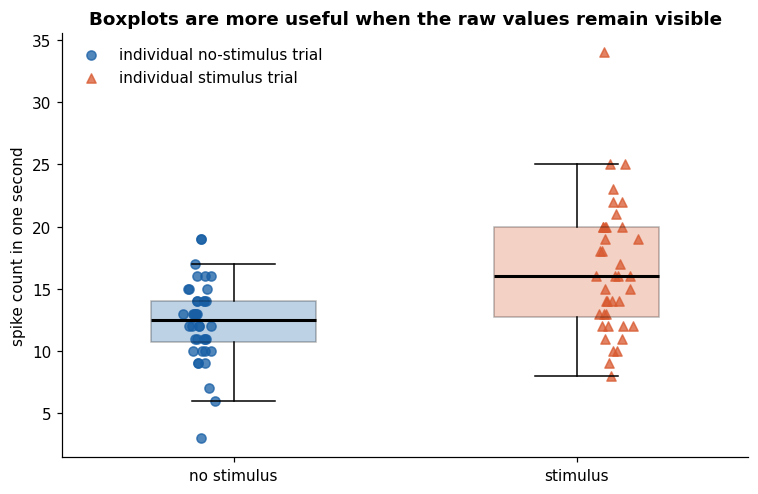

In [10]:
jitter_no = rng_plot.normal(-0.10, 0.025, size=N_TRIALS)
jitter_stim = rng_plot.normal(1.10, 0.025, size=N_TRIALS)

fig, ax = plt.subplots(figsize=(7, 4.6))
bp = ax.boxplot([no_stim, stim], positions=[0, 1], widths=0.48,
                patch_artist=True, showfliers=False,
                medianprops={"color": "black", "linewidth": 2})
for patch, colour in zip(bp["boxes"], [C_BASELINE, C_STIM]):
    patch.set_facecolor(colour)
    patch.set_alpha(0.28)

ax.scatter(jitter_no, no_stim, color=C_BASELINE, marker="o", alpha=0.75,
           label="individual no-stimulus trial")
ax.scatter(jitter_stim, stim, color=C_STIM, marker="^", alpha=0.75,
           label="individual stimulus trial")
ax.set_xticks([0, 1], ["no stimulus", "stimulus"])
ax.set_ylabel("spike count in one second")
ax.set_title("Boxplots are more useful when the raw values remain visible")
ax.legend(frameon=False, loc="upper left")
plt.tight_layout()
plt.show()

### How does the 1.5 × IQR rule work?

For each condition, calculate `Q1` and `Q3`, then flag values below `Q1 − 1.5 × IQR` or above `Q3 + 1.5 × IQR`. This is a flag for inspection, not an automatic delete command.

In [11]:
def iqr_outlier_report(values):
    q1, q3 = np.percentile(values, [25, 75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    flagged = values[(values < lower) | (values > upper)]
    return lower, upper, flagged

for label, values in (("no stimulus", no_stim), ("stimulus", stim)):
    lower, upper, flagged = iqr_outlier_report(values)
    print(f"{label:<12} accepted range [{lower:5.2f}, {upper:5.2f}]  flagged {flagged}")

outliers_stim = iqr_outlier_report(stim)[2]

no stimulus  accepted range [ 5.88, 18.88]  flagged [ 3. 19. 19.]
stimulus     accepted range [ 1.88, 30.88]  flagged [34.]


The rule also flags 3, 19, and 19 in the no-stimulus group. The simulation generated those values normally, and they are plausible for this neuron. These extra flags show why a numerical rule should start an investigation rather than finish one.

### Try it 3. What did the artefact change?

We know that 34 was injected rather than recorded, so we can compare the same sample with and without it. Before running the next cell, rank the mean, median, SD, and IQR from *most affected* to *least affected*. Then ask the more important question. Which of these summaries contributes to the denominator of the t-statistic later in the notebook?

In [12]:
stim_clean = np.delete(stim, 7)

comparison = pd.DataFrame({
    "as recorded": group_summary(stim),
    "artefact removed": group_summary(stim_clean),
})
comparison["absolute change"] = (
    comparison["artefact removed"] - comparison["as recorded"]
).abs()

comparison.loc[["mean", "median", "SD", "IQR"]].round(2)

,as recorded,artefact removed,absolute change
mean,16.48,16.03,0.45
median,16.00,16.00,0.00
SD,5.25,4.47,0.78
IQR,7.25,7.50,0.25


**Your answer**

I predicted the order SD, mean, median, IQR. The observed order was SD, mean, median, IQR. The summary most affected was SD, which matters for the later test because it contributes to the pooled standard deviation when looking at the Cohen's D . In a real experiment I would remove a trial only if it's an introduced artifact .

## 5. Why do larger samples give steadier answers?

The histogram above is a distribution of *individual trials*. Statistical inference often depends on a different object called a *sampling distribution*. Imagine repeating the whole experiment many times. Each repetition gives a new sample mean. The width of their distribution measures how much the estimate would vary from experiment to experiment.

Keep these two distributions separate.

- **Sample distribution** means the spread of individual trials in one experiment.
- **Sampling distribution** means the spread of an estimate across many repeated experiments.

The standard deviation of a sampling distribution is called a **standard error**.

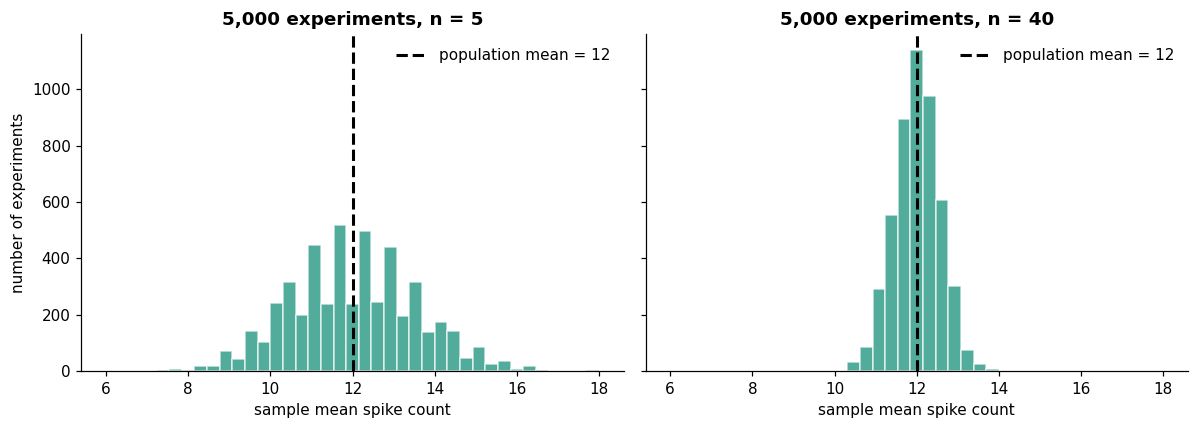

,trials per experiment,mean of sample means,SD of individual Poisson trials,observed SE of the mean,theoretical SE √(λ/n)
0,5,12.03,3.46,1.54,1.55
1,40,12.01,3.46,0.55,0.55


In [13]:
sampling_rng = np.random.default_rng(2028)
N_REPEATED_EXPERIMENTS = 5000
sampling_sizes = [5, 40]
sampling_means = {}

for n in sampling_sizes:
    repeated_samples = sampling_rng.poisson(
        TRUE_BASELINE, size=(N_REPEATED_EXPERIMENTS, n)
    )
    sampling_means[n] = repeated_samples.mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)
for ax, n in zip(axes, sampling_sizes):
    means = sampling_means[n]
    ax.hist(means, bins=np.linspace(6, 18, 40), color=C_NEURO,
            alpha=0.72, edgecolor="white")
    ax.axvline(TRUE_BASELINE, color="black", ls="--", lw=2,
               label=f"population mean = {TRUE_BASELINE:.0f}")
    ax.set_title(f"{N_REPEATED_EXPERIMENTS:,} experiments, n = {n}")
    ax.set_xlabel("sample mean spike count")
    ax.legend(frameon=False)
axes[0].set_ylabel("number of experiments")
plt.tight_layout()
plt.show()

sampling_table = pd.DataFrame({
    "trials per experiment": sampling_sizes,
    "mean of sample means": [sampling_means[n].mean() for n in sampling_sizes],
    "SD of individual Poisson trials": [np.sqrt(TRUE_BASELINE)] * 2,
    "observed SE of the mean": [sampling_means[n].std(ddof=1) for n in sampling_sizes],
    "theoretical SE √(λ/n)": [np.sqrt(TRUE_BASELINE / n) for n in sampling_sizes],
})
sampling_table.round(3)

Both sampling distributions are centred near 12 because the sample mean targets the same population mean. However, the distribution for 40 trials is much narrower. Averaging more observations cancels more of the trial-to-trial noise.

For an independent sample, the standard error of a mean is approximately

$$SE(\bar{x}) = \frac{s}{\sqrt{n}}.$$

Doubling `n` does not halve the standard error. To halve it, you need roughly four times as many independent observations.

### Try it 4. What changes when the sample size changes?

Edit `n_to_explore` below. Try 10, 20, 40, and 160. Before each run, predict the standard error. Then compare the simulation with the formula `√(λ/n)`.

In [26]:
n_to_explore = 30  # change me
explore_rng = np.random.default_rng(2029)
explore_means = explore_rng.poisson(
    TRUE_BASELINE, size=(N_REPEATED_EXPERIMENTS, n_to_explore)
).mean(axis=1)

observed_se = explore_means.std(ddof=1)
theoretical_se = np.sqrt(TRUE_BASELINE / n_to_explore)

print(f"n = {n_to_explore}")
print(f"observed standard error    = {observed_se:.3f}")
print(f"theoretical √(λ/n)         = {theoretical_se:.3f}")
print(f"typical sample mean range  ≈ {explore_means.mean():.2f} ± {2 * observed_se:.2f}")

n = 30
observed standard error    = 0.624
theoretical √(λ/n)         = 0.632
typical sample mean range  ≈ 12.01 ± 1.25


**Your answer**

When I changed `n` from 30 to 140, the standard error changed from about 0.624 to 0.292. This agrees with the `1/√n` rule because the standard error was closer to the theoretical value . The individual neuron did become less variable when I added trials.

## 6. What would we see if the stimulus did nothing?

Our observed effect is the difference between two sample means.

$$\text{observed difference} = \bar{x}_{\text{stimulus}} - \bar{x}_{\text{baseline}}.$$

Under the **null hypothesis** `H₀`, the stimulus label carries no information about the count. If that is true, any of the 80 counts could have received either label. We can therefore keep every observed value fixed, shuffle the labels, split the shuffled counts into two groups of 40, and recompute the difference.

One shuffle gives one difference from the null world. Ten thousand shuffles form a **permutation null distribution**.

In [27]:
mean_no = no_stim.mean()
mean_stim = stim.mean()
observed_diff = mean_stim - mean_no

print(f"mean without stimulus = {mean_no:.3f} spikes")
print(f"mean with stimulus    = {mean_stim:.3f} spikes")
print(f"observed difference   = {observed_diff:.3f} spikes")

mean without stimulus = 12.350 spikes
mean with stimulus    = 16.475 spikes
observed difference   = 4.125 spikes


Before running the permutation, make two predictions. Where should the shuffled differences be centred? How often do you expect a shuffled gap to be at least as far from zero as `±4.125` spikes?

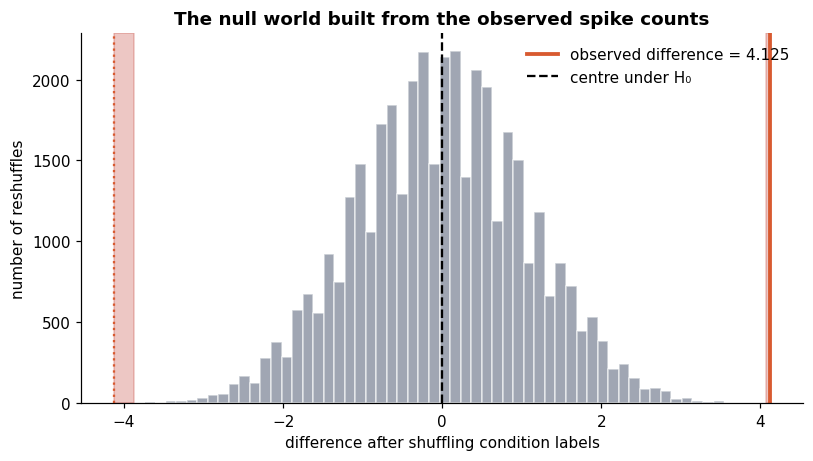

null distribution mean                 = -0.0048
shuffles at least as extreme as ±4.125 = 0
add-one permutation p-value             = 0.000025


In [51]:
N_PERMUTATIONS = 40000
perm_rng = np.random.default_rng(2027)
pooled_counts = np.concatenate([stim, no_stim])
perm_diffs = np.empty(N_PERMUTATIONS)

for i in range(N_PERMUTATIONS):
    shuffled = perm_rng.permutation(pooled_counts)
    perm_diffs[i] = shuffled[:N_TRIALS].mean() - shuffled[N_TRIALS:].mean()

perm_hits = int((np.abs(perm_diffs) >= abs(observed_diff)).sum())
permutation_p = (perm_hits + 1) / (N_PERMUTATIONS + 1)

fig, ax = plt.subplots(figsize=(7.5, 4.3))
ax.hist(perm_diffs, bins=60, color=C_NEUTRAL, alpha=0.62, edgecolor="white")
ax.axvspan(perm_diffs.min(), -abs(observed_diff), color=C_LOSS, alpha=0.28)
ax.axvspan(abs(observed_diff), perm_diffs.max(), color=C_LOSS, alpha=0.28)
ax.axvline(observed_diff, color=C_STIM, lw=2.5,
           label=f"observed difference = {observed_diff:.3f}")
ax.axvline(-observed_diff, color=C_STIM, lw=1.5, ls=":")
ax.axvline(0, color="black", lw=1.5, ls="--", label="centre under H₀")
ax.set_xlabel("difference after shuffling condition labels")
ax.set_ylabel("number of reshuffles")
ax.set_title("The null world built from the observed spike counts")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print(f"null distribution mean                 = {perm_diffs.mean():.4f}")
print(f"shuffles at least as extreme as ±{abs(observed_diff):.3f} = {perm_hits:,}")
print(f"add-one permutation p-value             = {permutation_p:.6f}")

The shaded tails are the results at least as extreme as the observed gap, in either direction. The p-value is their proportion under `H₀`. We use the add-one estimate `(hits + 1) / (permutations + 1)` so that a finite Monte Carlo sample never claims the probability is exactly zero.

### Try it 5. What does the shuffle represent?

1. Why does shuffling the labels represent `H₀`?
2. Why do we count both `+4.125` and `−4.125` as extreme?
3. What is the smallest non-zero add-one p-value this run can report?
4. Increase `N_PERMUTATIONS` to 50,000 if your machine allows it. Does the centre move? Does the p-value become more *precise* or does the observed effect become more *real*?

**Your answer**

Shuffling represents `H₀` because under the null hypothesis, the true difference between the stimulus and no stimulus means is zero. We count both tails because we want to see whether the stimulus has a positive or a negative effect on spike count. With 10,000 permutations the finest add-one resolution is 0.000100. More shuffles change p-value but do not change the shuffles at least as extreme as +/- 4.125.

## 7. How does a t-test quantify the same idea?

A permutation test constructs the null world from repeated shuffles. A t-test uses a mathematical null distribution. The **Welch two-sample t-test** compares independent means without assuming equal population variances.

We now state the hypotheses precisely.

$$H_0: \mu_{\text{stimulus}} - \mu_{\text{baseline}} = 0$$

$$H_1: \mu_{\text{stimulus}} - \mu_{\text{baseline}} \neq 0$$

The alternative is two-sided. We predicted an increase, but a large decrease would also be evidence that the stimulus changes this neuron's activity.

### What assumptions are we making?

The t-test is short code, but its assumptions come from the experiment.

1. **Independent observations.** One trial should not determine the next. Strong adaptation or temporal drift would challenge this.
2. **A suitable mean.** The scientific question must be expressible as a difference in average counts.
3. **A sufficiently regular sampling distribution.** The observations need not be perfectly Normal. With 40 independent trials per group, the sampling distribution of the mean is usually much more regular than the raw count distribution.
4. **No equal-variance assumption.** Welch's version estimates the two variances separately.

These assumptions cannot all be checked by a software function. The trial plot and experimental design carry part of the argument.

### Where does the t-statistic come from?

The t-statistic divides the estimated signal by its estimated noise.

$$t = \frac{\bar{x}_1 - \bar{x}_2}{\sqrt{\dfrac{s_1^2}{n_1} + \dfrac{s_2^2}{n_2}}} = \frac{\text{difference in means}}{\text{standard error of the difference}}.$$

We will calculate each part before calling SciPy.

In [34]:
n_stim, n_no = len(stim), len(no_stim)
var_stim = stim.var(ddof=1)
var_no = no_stim.var(ddof=1)

se_diff = np.sqrt(var_stim / n_stim + var_no / n_no)
t_manual = observed_diff / se_diff

parts = pd.DataFrame({
    "quantity": [
        "difference in means",
        "stimulus sample variance",
        "baseline sample variance",
        "standard error of the difference",
        "t = difference / standard error",
    ],
    "value": [observed_diff, var_stim, var_no, se_diff, t_manual],
})
parts.round(4)

,quantity,value
0,difference in means,4.12
1,stimulus sample variance,27.54
2,baseline sample variance,10.49
3,standard error of the difference,0.97
4,t = difference / standard error,4.23


`t ≈ 4.23` means that the observed difference is about 4.23 estimated standard errors from zero. To obtain a p-value, we compare `|t|` with a t-distribution using Welch's estimated degrees of freedom.

In [35]:
df_welch = (var_stim / n_stim + var_no / n_no) ** 2 / (
    (var_stim / n_stim) ** 2 / (n_stim - 1)
    + (var_no / n_no) ** 2 / (n_no - 1)
)

p_manual = 2 * stats.t.sf(abs(t_manual), df_welch)
t_scipy, p_scipy = stats.ttest_ind(stim, no_stim, equal_var=False)

print(f"hand calculation  t({df_welch:.2f}) = {t_manual:.4f}, p = {p_manual:.6f}")
print(f"SciPy Welch test               = {t_scipy:.4f}, p = {p_scipy:.6f}")
print(f"permutation test                           p = {permutation_p:.6f}")

hand calculation  t(64.95) = 4.2306, p = 0.000075
SciPy Welch test               = 4.2306, p = 0.000075
permutation test                           p = 0.000050


The t-test and permutation test nearly agree because both ask how unusual our observed separation would be under a no-effect world. They are not identical. Welch uses a smooth theoretical t-distribution, while the permutation result is a finite Monte Carlo estimate based on the observed counts.

### Where is the p-value on the null distribution?

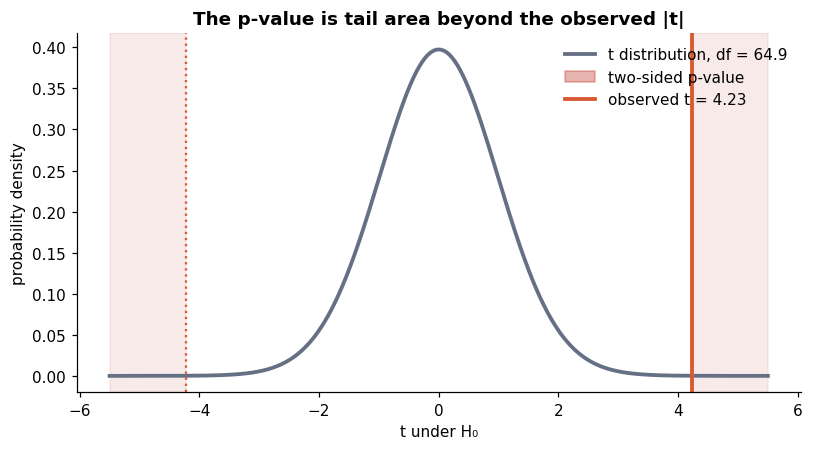

In [36]:
x_t = np.linspace(-5.5, 5.5, 1200)
y_t = stats.t.pdf(x_t, df_welch)
tail_mask = np.abs(x_t) >= abs(t_manual)

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(x_t, y_t, color=C_NEUTRAL, lw=2.5, label=f"t distribution, df = {df_welch:.1f}")
ax.fill_between(x_t, 0, y_t, where=tail_mask, color=C_LOSS, alpha=0.38,
                label="two-sided p-value")
ax.axvspan(x_t.min(), -abs(t_manual), color=C_LOSS, alpha=0.10)
ax.axvspan(abs(t_manual), x_t.max(), color=C_LOSS, alpha=0.10)
ax.axvline(t_manual, color=C_STIM, lw=2.5, label=f"observed t = {t_manual:.2f}")
ax.axvline(-t_manual, color=C_STIM, lw=1.5, ls=":")
ax.set(xlabel="t under H₀", ylabel="probability density",
       title="The p-value is tail area beyond the observed |t|")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

The pale bands mark the values that count as “at least as extreme”. The p-value is the area *under the t curve* inside those bands. The rectangular background marks the two regions.

### What does a 95% confidence interval add?

We use the p-value to assess how compatible the data are with a zero effect. A **confidence interval** keeps the effect in its original units and gives the range of population differences that remain reasonably compatible with the data.

For the difference in means, the 95% Welch interval is

$$\text{difference} \pm t^* \times SE(\text{difference}).$$

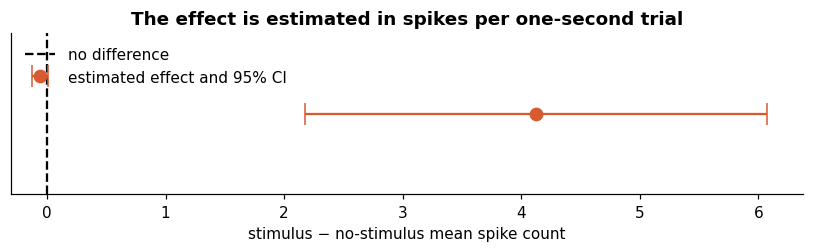

estimated difference = 4.125 spikes
95% CI               = [2.178, 6.072] spikes


In [37]:
t_critical = stats.t.ppf(0.975, df_welch)
ci_low = observed_diff - t_critical * se_diff
ci_high = observed_diff + t_critical * se_diff

fig, ax = plt.subplots(figsize=(7.5, 2.4))
ax.errorbar(observed_diff, 0,
            xerr=[[observed_diff - ci_low], [ci_high - observed_diff]],
            fmt="o", color=C_STIM, ecolor=C_STIM, capsize=7, markersize=8,
            label="estimated effect and 95% CI")
ax.axvline(0, color="black", ls="--", lw=1.5, label="no difference")
ax.set_yticks([])
ax.set_xlabel("stimulus − no-stimulus mean spike count")
ax.set_title("The effect is estimated in spikes per one-second trial")
ax.legend(frameon=False, loc="upper left")
plt.tight_layout()
plt.show()

print(f"estimated difference = {observed_diff:.3f} spikes")
print(f"95% CI               = [{ci_low:.3f}, {ci_high:.3f}] spikes")

If we repeated the full experiment many times and built an interval by the same procedure each time, about 95% of those intervals would contain the true population difference. The population difference is fixed. The interval changes from sample to sample.

### Try it 6. Which interpretations does the result support?

Decide whether the results support each statement.

1. “There is a 95% probability that the true effect lies inside this particular interval.”
2. “A zero mean difference is poorly compatible with the data and model.”
3. “The stimulus increases the mean count by exactly 4.125 spikes in the population.”
4. “The data estimate an increase of 4.125 spikes, with a 95% interval from about 2.18 to 6.07.”
5. “Because the interval excludes zero, the effect must be biologically important.”

**Your answer**

Statements 2 and 5 are supported. Statement 1 fails because we are not talking about the probability. Statement 3 fails because the 4.125 is the sample estimate, it could change given another sample. Statement 5 fails because statistical significance (or the interval excluding zero) does not automatically imply biological or practical importance.

## 8. How can a statistical decision be wrong?

A threshold such as `α = 0.05` turns a continuous p-value into a binary decision. Reality and the decision can then combine in four ways.

| | `H₀` is true | `H₀` is false |
|---|---|---|
| **Reject `H₀`** | **Type I error** or false positive | Correct detection |
| **Fail to reject `H₀`** | Correct non-rejection | **Type II error** or false negative |

The Type I error rate is `α`. The Type II error rate is `β`. **Power** is `1 − β`, the probability that the test detects a particular real effect.

### What happens when we move α?

We can simulate 4,000 experiments under a true null and another 4,000 under our true +3 spike effect. We then score the *same* experiments at several thresholds.

In [38]:
error_rng = np.random.default_rng(2030)
N_ERROR_EXPERIMENTS = 4000

null_a = error_rng.poisson(TRUE_BASELINE, size=(N_ERROR_EXPERIMENTS, N_TRIALS))
null_b = error_rng.poisson(TRUE_BASELINE, size=(N_ERROR_EXPERIMENTS, N_TRIALS))
_, p_null = stats.ttest_ind(null_b, null_a, axis=1, equal_var=False)

effect_a = error_rng.poisson(TRUE_BASELINE, size=(N_ERROR_EXPERIMENTS, N_TRIALS))
effect_b = error_rng.poisson(TRUE_STIM, size=(N_ERROR_EXPERIMENTS, N_TRIALS))
_, p_effect = stats.ttest_ind(effect_b, effect_a, axis=1, equal_var=False)

alpha_values = np.array([0.10, 0.05, 0.01, 0.001])
decision_table = pd.DataFrame({
    "α": alpha_values,
    "Type I rate": [(p_null < alpha).mean() for alpha in alpha_values],
    "power for true +3 effect": [(p_effect < alpha).mean() for alpha in alpha_values],
})
decision_table["Type II rate"] = 1 - decision_table["power for true +3 effect"]
decision_table.round(3)

,α,Type I rate,power for true +3 effect,Type II rate
0,1.00e-01,1.00e-01,0.97,0.03
1,5.00e-02,5.30e-02,0.95,0.05
2,1.00e-02,9.00e-03,0.83,0.17
3,1.00e-03,1.00e-03,0.58,0.42


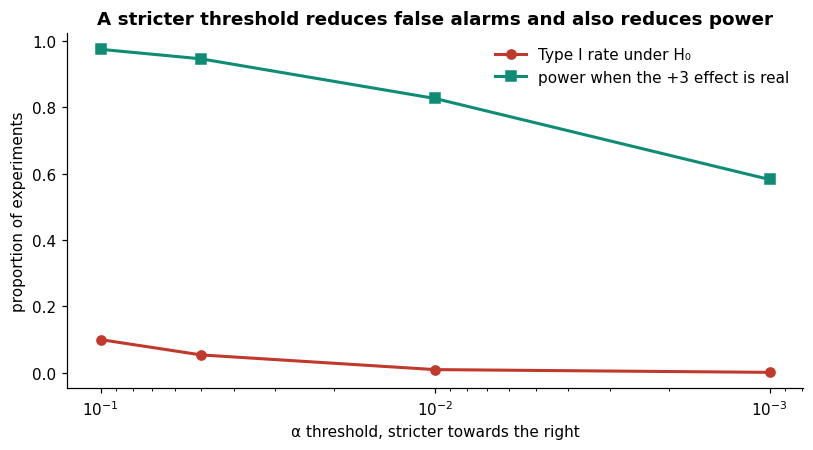

In [39]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(decision_table["α"], decision_table["Type I rate"], "o-",
        color=C_LOSS, lw=2, label="Type I rate under H₀")
ax.plot(decision_table["α"], decision_table["power for true +3 effect"], "s-",
        color=C_NEURO, lw=2, label="power when the +3 effect is real")
ax.set_xscale("log")
ax.invert_xaxis()
ax.set_xlabel("α threshold, stricter towards the right")
ax.set_ylabel("proportion of experiments")
ax.set_title("A stricter threshold reduces false alarms and also reduces power")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

Tightening `α` reduces false positives, but it also makes real effects harder to detect. A more informative experiment can reduce both error rates.

### How does sample size change power?

We now repeat the +3 spike experiment at several sample sizes. For each size we record the median `|t|`, the proportion with `p < 0.05`, and the median Cohen's `d`.

In [40]:
power_rng = np.random.default_rng(2031)
sample_sizes = [8, 12, 20, 40, 80]
N_POWER_REPEATS = 4000
power_rows = []

for n in sample_sizes:
    baseline_samples = power_rng.poisson(
        TRUE_BASELINE, size=(N_POWER_REPEATS, n)
    ).astype(float)
    stimulus_samples = power_rng.poisson(
        TRUE_STIM, size=(N_POWER_REPEATS, n)
    ).astype(float)

    t_values, p_values = stats.ttest_ind(
        stimulus_samples, baseline_samples, axis=1, equal_var=False
    )
    pooled_sd = np.sqrt(
        ((n - 1) * baseline_samples.var(axis=1, ddof=1)
         + (n - 1) * stimulus_samples.var(axis=1, ddof=1))
        / (2 * n - 2)
    )
    d_values = (
        stimulus_samples.mean(axis=1) - baseline_samples.mean(axis=1)
    ) / pooled_sd

    power_rows.append({
        "trials per group": n,
        "median |t|": np.median(np.abs(t_values)),
        "power at α = 0.05": np.mean(p_values < 0.05),
        "median Cohen's d": np.median(d_values),
    })

power_table = pd.DataFrame(power_rows)
power_table.round(3)

,trials per group,median |t|,power at α = 0.05,median Cohen's d
0,8,1.66,0.33,0.83
1,12,2.02,0.48,0.82
2,20,2.61,0.71,0.82
3,40,3.64,0.95,0.81
4,80,5.17,1.00,0.82


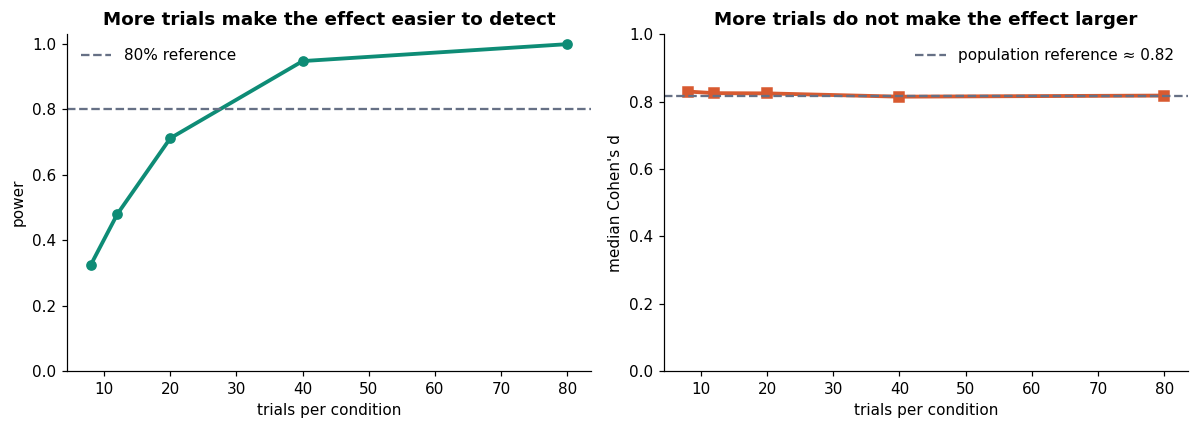

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(power_table["trials per group"], power_table["power at α = 0.05"],
             "o-", color=C_NEURO, lw=2.5)
axes[0].axhline(0.80, color=C_NEUTRAL, ls="--", label="80% reference")
axes[0].set(xlabel="trials per condition", ylabel="power",
            title="More trials make the effect easier to detect", ylim=(0, 1.03))
axes[0].legend(frameon=False)

axes[1].plot(power_table["trials per group"], power_table["median Cohen's d"],
             "s-", color=C_STIM, lw=2.5)
population_d_reference = TRUE_EFFECT / np.sqrt((TRUE_BASELINE + TRUE_STIM) / 2)
axes[1].axhline(population_d_reference, color=C_NEUTRAL, ls="--",
                label=f"population reference ≈ {population_d_reference:.2f}")
axes[1].set(xlabel="trials per condition", ylabel="median Cohen's d",
            title="More trials do not make the effect larger", ylim=(0, 1.0))
axes[1].legend(frameon=False)
plt.tight_layout()
plt.show()

`t` and power rise with sample size because the standard error shrinks. Cohen's `d` stays close to the same value because it divides by the variability of individual trials. As `n` grows, the estimate becomes more precise while the underlying effect stays fixed.

### Try it 7. Which error can you live with?

Consider a system that uses neural activity to trigger a painful intervention.

1. Which error is more serious, a false positive or a false negative?
2. Would you prefer `α = 0.10`, `0.05`, or `0.01` if sample size could not change?
3. What would you change in the experiment to reduce both error rates?
4. At roughly what sample size does the simulated +3 effect first exceed 80% power?

There is no universally correct threshold. The answer depends on the consequences of the two errors and on the information available.

**Your answer**

In this setting the more serious error is false positive because it would lead to more pain. I would choose α = 0.01 given the constraint. To reduce both errors I would change the sample size. The simulated effect first exceeds 80% power at about 40 trials per condition.

## 9. How large is the effect, and does it matter?

The p-value and confidence interval address uncertainty about the mean difference. They do not, by themselves, say whether the separation is large relative to trial-to-trial variability. **Cohen's d** expresses the mean difference in pooled standard-deviation units.

$$d = \frac{\bar{x}_{\text{stimulus}} - \bar{x}_{\text{baseline}}}{s_{\text{pooled}}}$$

Keep the raw difference in the report because spikes per trial are biologically interpretable. Cohen's `d` helps us compare measurements expressed in different units.

In [42]:
s_pooled = np.sqrt(
    ((n_stim - 1) * var_stim + (n_no - 1) * var_no)
    / (n_stim + n_no - 2)
)
cohens_d = observed_diff / s_pooled

effect_summary = pd.DataFrame({
    "quantity": ["raw mean difference", "95% CI lower", "95% CI upper", "pooled SD", "Cohen's d"],
    "value": [observed_diff, ci_low, ci_high, s_pooled, cohens_d],
    "units": ["spikes", "spikes", "spikes", "spikes", "pooled SDs"],
})
effect_summary.round(3)

,quantity,value,units
0,raw mean difference,4.12,spikes
1,95% CI lower,2.18,spikes
2,95% CI upper,6.07,spikes
3,pooled SD,4.36,spikes
4,Cohen's d,0.95,pooled SDs


Rules such as `d ≈ 0.2` for small, `0.5` for medium, and `0.8` for large are descriptive conventions. Biological importance depends on the setting. A small standardised effect can matter in a high-stakes application, while a large one can be uninteresting if the manipulation is artificial or the outcome is irrelevant.

### Why can a tiny effect have a tiny p-value?

Take a true effect of only +0.3 spikes and collect 5,000 trials per group. The large sample makes that small difference precisely estimated.

In [45]:
tiny_rng = np.random.default_rng(2032)
BIG_N = 5000
tiny_a = tiny_rng.poisson(TRUE_BASELINE, size=BIG_N).astype(float)
tiny_b = tiny_rng.poisson(TRUE_BASELINE + 0.3, size=BIG_N).astype(float)

_, p_tiny = stats.ttest_ind(tiny_b, tiny_a, equal_var=False)
sp_tiny = np.sqrt(
    ((BIG_N - 1) * tiny_a.var(ddof=1) + (BIG_N - 1) * tiny_b.var(ddof=1))
    / (2 * BIG_N - 2)
)
d_tiny = (tiny_b.mean() - tiny_a.mean()) / sp_tiny
raw_tiny = tiny_b.mean() - tiny_a.mean()

print(f"mean difference = {raw_tiny:.3f} spikes")
print(f"p-value         = {p_tiny:.6f}")
print(f"Cohen's d       = {d_tiny:.3f}")

mean difference = 0.314 spikes
p-value         = 0.000008
Cohen's d       = 0.089


The p-value is small because the zero-effect model struggles to explain the precision of the estimate. The raw difference and `d` are small because the detected shift itself is modest. Both statements can be true.

### Try it 8. How would you review these two claims?

You are reviewing two papers that claim a manipulation raises firing rate. Neither reports a confidence interval.

| | Study A | Study B |
|---|---:|---:|
| trials per condition | 4,000 | 18 |
| reported `p` | 0.002 | 0.04 |
| Cohen's `d` | 0.07 | 0.71 |

1. Which study provides stronger evidence against `H₀`?
2. Which reports the more interesting estimated size?
3. Why should `d = 0.71` from 18 trials make you cautious about the size?
4. Write two sentences you would put in the review of Study A.
5. What additional estimate should both papers report?

**Your answer**

Study A provides stronger evidence against `H₀`, while Study B reports the larger estimated effect. I am cautious about Study B because it reports a big difference in effect with small trials. My review of Study A would say the reported p-value here doesn't mean the effect is large, but rather that the observed, although small, effect is highly unlikely if the true effect were zero, given the high precision of the estimate. Both papers should report standard errors and confidence intervals .

## 10. What does `p < 0.05` actually mean?

The p-value is the probability, **assuming `H₀` and the test model**, of obtaining a test statistic at least as extreme as the one observed. It is written as `P(data this extreme or more | H₀)`. It is not `P(H₀ | data)`.

For our experiment, `p < 0.05` supports the statement that a zero mean difference is poorly compatible with the data and assumptions. It does not support any of the following on its own.

- “There is a 95% chance that the effect is real.”
- “The effect is large.”
- “The result will replicate.”
- “The design is unbiased.”
- “The Poisson model is true.”
- “A result with `p = 0.049` is meaningfully different from one with `p = 0.051`.”

A complete result reports the estimate, uncertainty, test, and scientific interpretation together.

## 11. How does this return us to the regression from Lecture 1?

*Part 11 is optional.* It introduces no new statistical test. Instead, it connects today's comparison with the regression you fitted in Lecture 1.

A t-test compares two group means. A regression predicts an outcome from one or more inputs. These look like different jobs until the condition is encoded as a number.

Set `x = 0` for no stimulus and `x = 1` for stimulus, then fit

$$\widehat{y} = \theta_0 + \theta_1 x.$$

At `x = 0`, the prediction is `θ₀`. At `x = 1`, the prediction is `θ₀ + θ₁`. The fitted weight must therefore be the difference between the two group means.

### Try it 9 (optional). What will the regression parameters be?

Before running the next cell, predict `θ₀` and `θ₁` from the two sample means. Then check whether the fitted weight's t-statistic matches the t-test.

In [46]:
from sklearn.linear_model import LinearRegression

x_binary = df[["stimulus_on"]].to_numpy()
y_counts = df["spike_count"].to_numpy()

group_model = LinearRegression().fit(x_binary, y_counts)
regression_predictions = group_model.predict(x_binary)
regression_residuals = y_counts - regression_predictions

# Residual variance for a model with two fitted parameters, then the OLS slope SE.
residual_variance = np.sum(regression_residuals ** 2) / (len(y_counts) - 2)
x_centred_sum_squares = np.sum((x_binary.ravel() - x_binary.mean()) ** 2)
se_weight = np.sqrt(residual_variance / x_centred_sum_squares)
t_weight = group_model.coef_[0] / se_weight

print(f"regression bias  θ₀ = {group_model.intercept_:.4f}")
print(f"regression weight θ₁ = {group_model.coef_[0]:.4f}")
print(f"weight standard error = {se_weight:.4f}")
print(f"weight t-statistic    = {t_weight:.4f}")
print()
print(f"no-stimulus mean      = {mean_no:.4f}")
print(f"difference in means   = {observed_diff:.4f}")
print(f"Welch t-statistic     = {t_scipy:.4f}")

regression bias  θ₀ = 12.3500
regression weight θ₁ = 4.1250
weight standard error = 0.9750
weight t-statistic    = 4.2306

no-stimulus mean      = 12.3500
difference in means   = 4.1250
Welch t-statistic     = 4.2306


With equal group sizes, the regression weight and Welch t-statistic match to the displayed precision. The regression obtains the standard error from the residual spread around the two fitted group means. It is measuring the same signal against the same trial-to-trial noise.

Now change the coding from `0/1` to `−1/+1`. Do not run the next cell until you have predicted what happens to the bias and weight.

In [54]:
x_pm = np.where(df["stimulus_on"].to_numpy() == 0, -1.0,1.0).reshape(-1, 1)
pm_model = LinearRegression().fit(x_pm, y_counts)

print(f"with −1/+1 coding, bias   = {pm_model.intercept_:.4f}")
print(f"with −1/+1 coding, weight = {pm_model.coef_[0]:.4f}")
print(f"midpoint of group means   = {(mean_no + mean_stim) / 2:.4f}")
print(f"half the mean difference  = {observed_diff / 2:.4f}")

with −1/+1 coding, bias   = 14.4125
with −1/+1 coding, weight = 2.0625
midpoint of group means   = 14.4125
half the mean difference  = 2.0625


**Your answer**

With `0/1` coding I predicted `θ₀ = 12` and `θ₁ = 4`. They equal 12.3500 and 4.1250. With `−1/+1` coding the bias becomes 14.4125 and the weight becomes 2.0625 because, the distance now is 2, the weight has to be halfed .

## 12. What can we conclude from this experiment?

A statistical report should let the reader reconstruct the claim. It should include the group summaries, the estimated effect in original units, uncertainty, the test and its degrees of freedom, the exact p-value when practical, and a standardised effect if comparison across measures is useful.

In [48]:
result_sentence = (
    f"Neuron 17 produced {mean_stim:.2f} spikes per stimulus trial and "
    f"{mean_no:.2f} per no-stimulus trial. The estimated increase was "
    f"{observed_diff:.2f} spikes (95% CI [{ci_low:.2f}, {ci_high:.2f}]), "
    f"Welch t({df_welch:.1f}) = {t_scipy:.2f}, p = {p_scipy:.6f}, "
    f"Cohen's d = {cohens_d:.2f}."
)
print(result_sentence)

Neuron 17 produced 16.48 spikes per stimulus trial and 12.35 per no-stimulus trial. The estimated increase was 4.13 spikes (95% CI [2.18, 6.07]), Welch t(64.9) = 4.23, p = 0.000075, Cohen's d = 0.95.


Under the Welch-test model, the data are difficult to reconcile with equal mean counts in the two conditions. However, we have analysed one simulated neuron under a simplified data-generating model. Generalisation across V1 neurons, animals, and recording conditions requires another experiment.

A natural next experiment would record multiple neurons across animals and sessions, preserve the trial order, pre-specify artefact handling, and model the nested structure. That returns us to the first stage of the scientific loop with a sharper question.

### Try it 10. How would you write the scientific conclusion?

Write four sentences.

1. State the estimated effect and its uncertainty.
2. Interpret the p-value under `H₀`.
3. State whether the effect seems large enough to care about and what knowledge that judgment requires.
4. Name the most useful next experiment or measurement.

**Your answer**

The stimulus increased the mean spike count. Under a zero-effect model, the observed difference of the magnitude we saw in the p-value would be extremely rare if the stimulus had no effect on the neuron's firing rate. In biological terms, we can't say much until we incorporate the cohen's d. The next experiment should be to record from more neurons because to get better response profile .

## Automated checks

Run the cell below after working through the notebook. Each assertion checks one idea or numerical link. If one fails after you have experimented with the code, the message tells you which section to rerun.

In [55]:
# Data integrity.
assert len(df) == 80, "The experiment should contain 80 trials. Rerun Part 2."
assert df["condition"].value_counts().eq(40).all(), "Each condition should contain 40 trials."
assert df["spike_count"].isna().sum() == 0, "The simulated dataset should contain no missing counts."

# EDA and artefact handling.
assert 34.0 in outliers_stim, "The 1.5×IQR rule should flag the injected 34-spike artefact."
assert len(stim_clean) == N_TRIALS - 1, "Removing the known artefact should remove exactly one trial."
assert stim_clean.std(ddof=1) < stim.std(ddof=1), "The known artefact should inflate the stimulus-group SD."

# Sampling distribution.
assert sampling_means[40].std(ddof=1) < sampling_means[5].std(ddof=1), "More trials should narrow the sampling distribution."
assert abs(sampling_means[40].mean() - TRUE_BASELINE) < 0.1, "Sample means should centre near the population mean."

# Permutation null.
assert perm_diffs.shape == (N_PERMUTATIONS,), "Store one difference for every permutation."
assert abs(perm_diffs.mean()) < 0.1, "The permutation null should centre near zero."
assert 0 < permutation_p < 0.001, "The observed difference should be rare under shuffled labels."

# T-test and confidence interval.
assert abs(t_manual - t_scipy) < 1e-10, "The hand-computed and SciPy t-statistics should match."
assert abs(p_manual - p_scipy) < 1e-10, "The hand-computed and SciPy p-values should match."
assert ci_low < observed_diff < ci_high, "The point estimate should sit inside its confidence interval."
assert ci_low > 0, "This experiment's 95% interval should exclude a zero mean difference."

# Errors and effect size.
assert abs((p_null < 0.05).mean() - 0.05) < 0.02, "The false-positive rate should sit near α = 0.05."
assert power_table["power at α = 0.05"].iloc[-1] > power_table["power at α = 0.05"].iloc[0], "Power should rise with sample size."
assert s_pooled > 0 and cohens_d > 0, "The stimulus effect and Cohen's d should be positive."
assert p_tiny < 0.05 and abs(d_tiny) < 0.2, "The large-sample example should be detectable but small."

# Optional regression bridge.
if "group_model" in globals():
    assert abs(group_model.intercept_ - mean_no) < 1e-10, "The 0/1-coded bias should equal the baseline mean."
    assert abs(group_model.coef_[0] - observed_diff) < 1e-10, "The 0/1-coded weight should equal the difference in means."
    assert abs(t_weight - t_scipy) < 1e-10, "With equal group sizes, the weight t should match Welch's t."

print("All automated checks passed.")

All automated checks passed.


## What should you submit?

Before saving your copy, check that you have done the following.

- Run every code cell in the main route from top to bottom.
- Write something in Try it 1–8 and Try it 10.
- Complete Try it 9 if you take the optional regression route.
- Change at least one sample size or analysis setting and explain what happened.
- Run the automated checks successfully.
- Write one question you would now ask about the experiment.

**Optional feedback for the lecturer**

- Which section changed your understanding most?
- Where did you first lose the thread?
- Roughly how long did the notebook take?
- If you used an AI assistant, what did it help with, and how did you check its answer?

*NB-3 applies the same reasoning to classification decisions.*